[Oregon Curriculum Network](http://4dsolutions.net/ocn/)<br/>
[School of Tomorrow](School_of_Tomorrow.ipynb)

# PRINTING POLYS

How might we use the existing `flextegrity.py` framework, wherein our concentric hierarchy is already defined, to produce files usable by 3D printers?

I started by consulting experts and by running [a query](https://www.perplexity.ai/search/i-have-the-xyz-coordinates-of-nos_eDj9S9GfW3guoiN0Qw#0) through the Perplexity LLM.

The AI bot suggested using numpy-stl. Given I use the Anaconda distro, I'll install it from there.

In [1]:
# ! conda install conda-forge::numpy-stl

I chose to open a terminal at this point, to carry out the above Package Plan.

<a data-flickr-embed="true" href="https://www.flickr.com/photos/kirbyurner/55112237117/in/dateposted/" title="Installing numpy-stl from conda-forge"><img src="https://live.staticflickr.com/65535/55112237117_f0a53f402b.jpg" width="500" height="414" alt="Installing numpy-stl from conda-forge"/></a><script async src="//embedr.flickr.com/assets/client-code.js" charset="utf-8"></script>

1-2-3 testing...

In [2]:
import numpy as np
from stl import mesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

Looking good.

For now, we'll leave the code in `flextegrity.py` as it is and do all our development work externally, using numpy-stl.  

Lets get to work with our already omni-triangulated shapes, already amenable to direct STL output without further adieu.

In [3]:
from flextegrity import Tetrahedron, Icosahedron, Octahedron, Amod

In [4]:
tet = Tetrahedron()
oc = Octahedron()
icosa = Icosahedron()

amod = Amod()

I had Gemini on Google Colab help me write the code below. 

*Prompt*:  use numpy-stl to define a cube and then display it using pyplot

I then cannibalized the resulting code and combined it with mine to get:

In [5]:
def plot_shape(the_shape):

    name  = the_shape.name
    faces = the_shape.faces
    verts = {k:[v.xyz.x.evalf().round(10), v.xyz.y.evalf().round(10), v.xyz.z.evalf().round(10)] for k,v in the_shape.vertexes.items()}
    vertices = np.array(list(verts.values()), dtype=float)  # needed below  

    the_mesh = mesh.Mesh(np.zeros(len(faces), dtype=mesh.Mesh.dtype))
    for i, f in enumerate(faces):
        for idx, j in enumerate(f):
            the_mesh.vectors[i][idx] = np.array(verts[j])

    # Optionally, calculate normals. While not strictly needed for display with Poly3DCollection,
    # it's good practice for STL files.
    the_mesh.update_normals()

    # Optional: Save the STL file
    the_mesh.save('{}.stl'.format(name))
    print("{0} saved to {0}.stl".format(name))

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Create a Poly3DCollection from the mesh's vectors
    # mesh.vectors is already in the correct format: an array of (N, 3, 3) where N is the
    # number of triangles, and each (3,3) array represents the 3 vertices of a triangle.
    poly3d = Poly3DCollection(the_mesh.vectors, alpha=0.6, facecolor='cyan', edgecolor='black')
    ax.add_collection3d(poly3d)
    
    # Set plot limits and labels
    # Determine the bounding box for proper scaling
    min_coords = np.min(vertices, axis=0)
    max_coords = np.max(vertices, axis=0)
    max_range = np.array([max_coords - min_coords]).max() # Max extent across any dimension
    
    mid_x = (min_coords[0] + max_coords[0]) / 2.0
    mid_y = (min_coords[1] + max_coords[1]) / 2.0
    mid_z = (min_coords[2] + max_coords[2]) / 2.0
    
    # Set equal aspect ratio
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Numpy-STL {} Displayed with Matplotlib'.format(name))
    ax.grid(True)
    
    plt.show()

Tetrahedron saved to Tetrahedron.stl


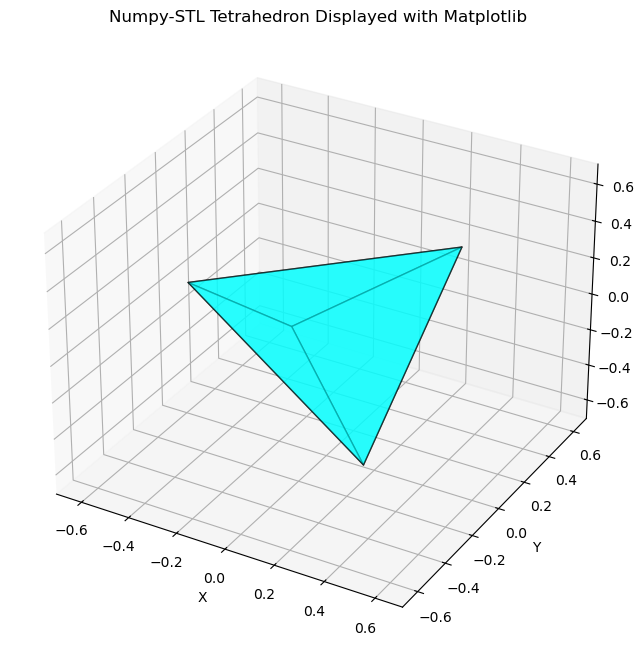

In [6]:
plot_shape(tet)

Octahedron saved to Octahedron.stl


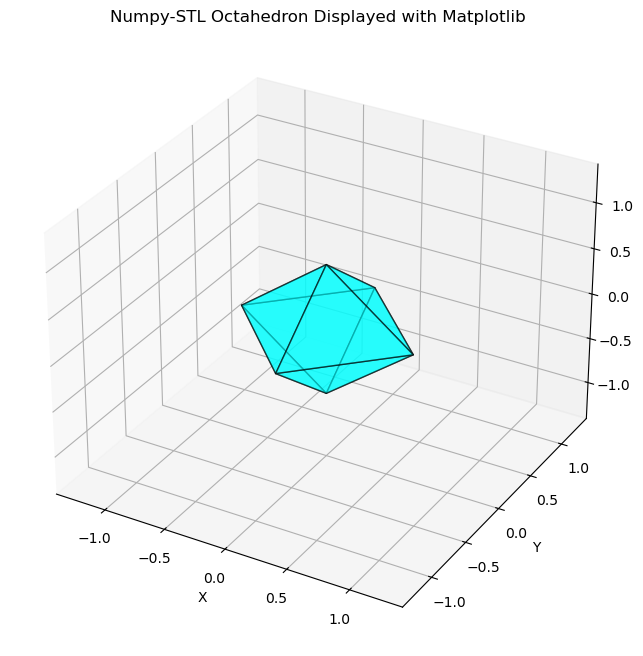

In [7]:
plot_shape(oc)

Icosahedron saved to Icosahedron.stl


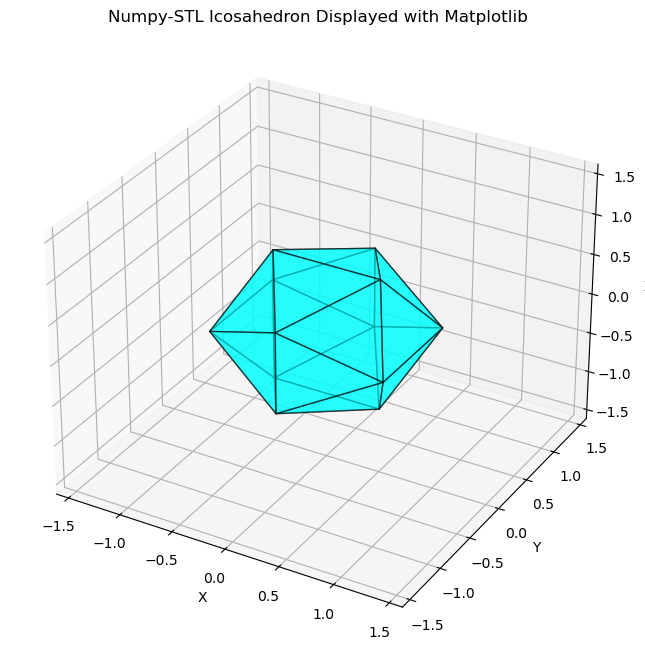

In [8]:
plot_shape(icosa)

Amod saved to Amod.stl


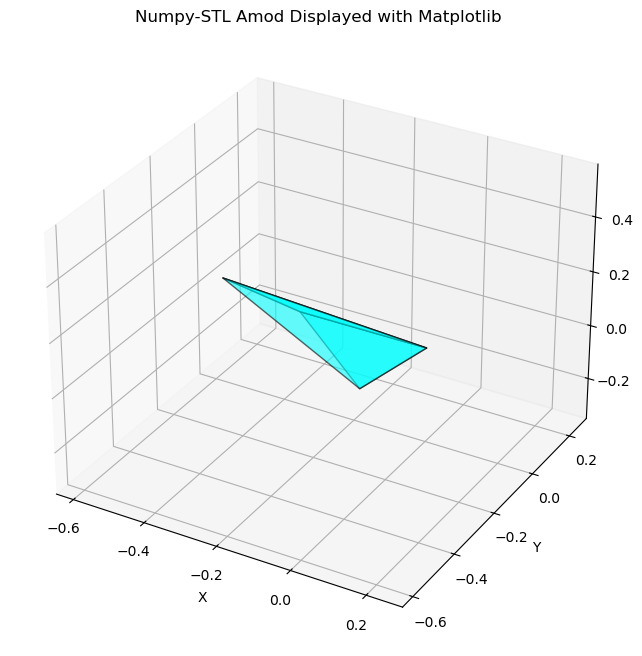

In [9]:
plot_shape(amod)

## For Further Reading

* [The QuadCraft Project](QuadCraft_Project.ipynb)
* [Making Shapes](Shapes_Framework.ipynb)
* [Vanes](Vanes.ipynb) 